<a href="https://colab.research.google.com/github/sathishgowdaRS/ML-MINI-PROJECT/blob/main/Flood_Risk_Level_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q pandas numpy matplotlib seaborn scikit-learn joblib


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    GridSearchCV
)

from sklearn.preprocessing import (
    StandardScaler,
    LabelEncoder
)

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import joblib

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
from google.colab import files

uploaded = files.upload()

Saving flood_risk_dataset_india.csv.zip to flood_risk_dataset_india.csv.zip


In [14]:
import zipfile
import os

# Unzip the uploaded file
with zipfile.ZipFile('flood_risk_dataset_india.csv.zip', 'r') as zip_ref:
    zip_ref.extractall('.')

# Now read the CSV file
df = pd.read_csv('flood_risk_dataset_india.csv')

print("Dataset loaded successfully!")
print(df.shape)

Dataset loaded successfully!
(10000, 14)


In [15]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 10000
Number of columns: 14


In [16]:
print("Columns in the dataset:")
for i, col in enumerate(df.columns, 1):
    print(i, ":", col)

Columns in the dataset:
1 : Latitude
2 : Longitude
3 : Rainfall (mm)
4 : Temperature (°C)
5 : Humidity (%)
6 : River Discharge (m³/s)
7 : Water Level (m)
8 : Elevation (m)
9 : Land Cover
10 : Soil Type
11 : Population Density
12 : Infrastructure
13 : Historical Floods
14 : Flood Occurred


In [17]:
df.head(10)

,Latitude,Longitude,Rainfall (mm),Temperature (°C),Humidity (%),River Discharge (m³/s),Water Level (m),Elevation (m),Land Cover,Soil Type,Population Density,Infrastructure,Historical Floods,Flood Occurred
0,18.861663,78.835584,218.999493,34.144337,43.912963,4236.182888,7.415552,377.465433,Water Body,Clay,7276.742184,1,0,1
1,35.570715,77.654451,55.353599,28.778774,27.585422,2472.585219,8.811019,7330.608875,Forest,Peat,6897.736956,0,1,0
2,29.227824,73.108463,103.991908,43.934956,30.108738,977.328053,4.631799,2205.873488,Agricultural,Loam,4361.518494,1,1,1
3,25.361096,85.610733,198.984191,21.569354,34.453690,3683.208933,2.891787,2512.277800,Desert,Sandy,6163.069701,1,1,0
4,12.524541,81.822101,144.626803,32.635692,36.292267,2093.390678,3.188466,2001.818223,Agricultural,Loam,6167.964591,1,0,0
5,12.523841,93.105329,221.571312,36.006300,39.380945,2973.137417,6.969483,7433.062836,Agricultural,Loam,5377.538809,0,0,1
6,9.684425,68.931178,288.362370,39.766935,40.436802,536.326451,5.675580,8661.324855,Water Body,Silt,6039.090369,0,0,1
7,33.119108,86.672170,34.964006,27.209131,56.457308,3157.919948,4.864941,6681.891487,Agricultural,Clay,3994.453680,0,1,1
8,25.432335,90.125517,212.870315,35.607657,60.765855,1867.752445,2.027741,7287.016909,Forest,Silt,6782.941225,0,0,0
9,28.534105,90.025111,69.103247,24.096044,44.710337,1670.948749,8.754557,5490.188075,Urban,Silt,2270.032224,0,1,0


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Latitude                10000 non-null  float64
 1   Longitude               10000 non-null  float64
 2   Rainfall (mm)           10000 non-null  float64
 3   Temperature (°C)        10000 non-null  float64
 4   Humidity (%)            10000 non-null  float64
 5   River Discharge (m³/s)  10000 non-null  float64
 6   Water Level (m)         10000 non-null  float64
 7   Elevation (m)           10000 non-null  float64
 8   Land Cover              10000 non-null  object 
 9   Soil Type               10000 non-null  object 
 10  Population Density      10000 non-null  float64
 11  Infrastructure          10000 non-null  int64  
 12  Historical Floods       10000 non-null  int64  
 13  Flood Occurred          10000 non-null  int64  
dtypes: float64(9), int64(3), object(2)
memo

In [19]:
missing = df.isnull().sum()

print("Missing values:")
print(missing)

Missing values:
Latitude                  0
Longitude                 0
Rainfall (mm)             0
Temperature (°C)          0
Humidity (%)              0
River Discharge (m³/s)    0
Water Level (m)           0
Elevation (m)             0
Land Cover                0
Soil Type                 0
Population Density        0
Infrastructure            0
Historical Floods         0
Flood Occurred            0
dtype: int64


In [20]:
missing_percentage = (
    df.isnull().sum() / len(df) * 100
).sort_values(ascending=False)

print(missing_percentage)

Latitude                  0.0
Longitude                 0.0
Rainfall (mm)             0.0
Temperature (°C)          0.0
Humidity (%)              0.0
River Discharge (m³/s)    0.0
Water Level (m)           0.0
Elevation (m)             0.0
Land Cover                0.0
Soil Type                 0.0
Population Density        0.0
Infrastructure            0.0
Historical Floods         0.0
Flood Occurred            0.0
dtype: float64


In [22]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [23]:
df = df.drop_duplicates().reset_index(drop=True)

print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (10000, 14)


In [24]:
df.describe()

,Latitude,Longitude,Rainfall (mm),Temperature (°C),Humidity (%),River Discharge (m³/s),Water Level (m),Elevation (m),Population Density,Infrastructure,Historical Floods,Flood Occurred
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,22.330627,82.631366,150.015118,29.961401,59.749104,2515.722946,5.017881,4417.138177,5021.468442,0.502000,0.498700,0.505700
std,8.341274,8.389542,86.032127,8.669838,23.142734,1441.706442,2.876579,2530.245421,2882.591520,0.500021,0.500023,0.499993
min,8.000337,68.004575,0.014437,15.000166,20.001339,0.042161,0.002701,1.150340,2.289000,0.000000,0.000000,0.000000
25%,15.143537,75.364428,76.124373,22.405717,39.541778,1284.782376,2.538847,2229.681903,2491.766601,0.000000,0.000000,0.000000
50%,22.283330,82.671007,150.620428,30.000907,59.497375,2530.451944,5.042094,4417.199761,5074.392879,1.000000,0.000000,1.000000
75%,29.460184,89.937897,223.402156,37.413488,80.038163,3767.229862,7.524692,6616.729066,7474.228752,1.000000,1.000000,1.000000
max,36.991813,96.997820,299.970293,44.993681,99.997772,4999.698480,9.996899,8846.894877,9999.169530,1.000000,1.000000,1.000000


In [25]:
df.describe(include="all")

,Latitude,Longitude,Rainfall (mm),Temperature (°C),Humidity (%),River Discharge (m³/s),Water Level (m),Elevation (m),Land Cover,Soil Type,Population Density,Infrastructure,Historical Floods,Flood Occurred
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000,10000,10000.000000,10000.000000,10000.000000,10000.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,5,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Water Body,Peat,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2046,2052,NaN,NaN,NaN,NaN
mean,22.330627,82.631366,150.015118,29.961401,59.749104,2515.722946,5.017881,4417.138177,NaN,NaN,5021.468442,0.502000,0.498700,0.505700
std,8.341274,8.389542,86.032127,8.669838,23.142734,1441.706442,2.876579,2530.245421,NaN,NaN,2882.591520,0.500021,0.500023,0.499993
min,8.000337,68.004575,0.014437,15.000166,20.001339,0.042161,0.002701,1.150340,NaN,NaN,2.289000,0.000000,0.000000,0.000000
25%,15.143537,75.364428,76.124373,22.405717,39.541778,1284.782376,2.538847,2229.681903,NaN,NaN,2491.766601,0.000000,0.000000,0.000000
50%,22.283330,82.671007,150.620428,30.000907,59.497375,2530.451944,5.042094,4417.199761,NaN,NaN,5074.392879,1.000000,0.000000,1.000000
75%,29.460184,89.937897,223.402156,37.413488,80.038163,3767.229862,7.524692,6616.729066,NaN,NaN,7474.228752,1.000000,1.000000,1.000000


In [26]:
print(df.columns.tolist())

['Latitude', 'Longitude', 'Rainfall (mm)', 'Temperature (°C)', 'Humidity (%)', 'River Discharge (m³/s)', 'Water Level (m)', 'Elevation (m)', 'Land Cover', 'Soil Type', 'Population Density', 'Infrastructure', 'Historical Floods', 'Flood Occurred']


In [27]:
TARGET = "Flood Occurred"

In [29]:
print(df[TARGET].value_counts())

Flood Occurred
1    5057
0    4943
Name: count, dtype: int64


In [30]:
print(df[TARGET].value_counts(normalize=True) * 100)

Flood Occurred
1    50.57
0    49.43
Name: proportion, dtype: float64


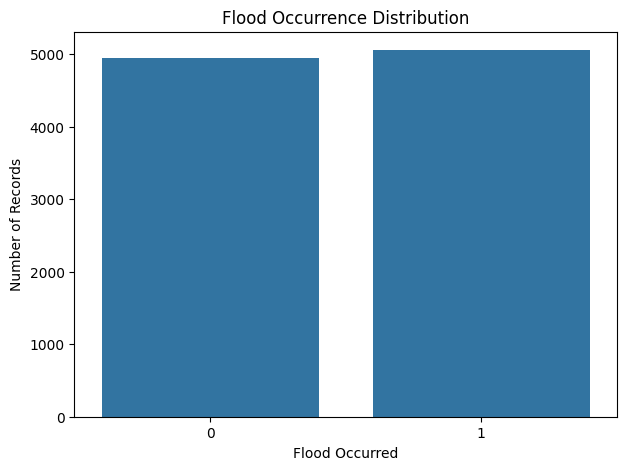

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x=TARGET
)

plt.title("Flood Occurrence Distribution")
plt.xlabel("Flood Occurred")
plt.ylabel("Number of Records")

plt.show()

In [32]:
numeric_columns = df.select_dtypes(
    include=["int64", "float64"]
).columns

print("Numerical columns:")
print(numeric_columns.tolist())

Numerical columns:
['Latitude', 'Longitude', 'Rainfall (mm)', 'Temperature (°C)', 'Humidity (%)', 'River Discharge (m³/s)', 'Water Level (m)', 'Elevation (m)', 'Population Density', 'Infrastructure', 'Historical Floods', 'Flood Occurred']


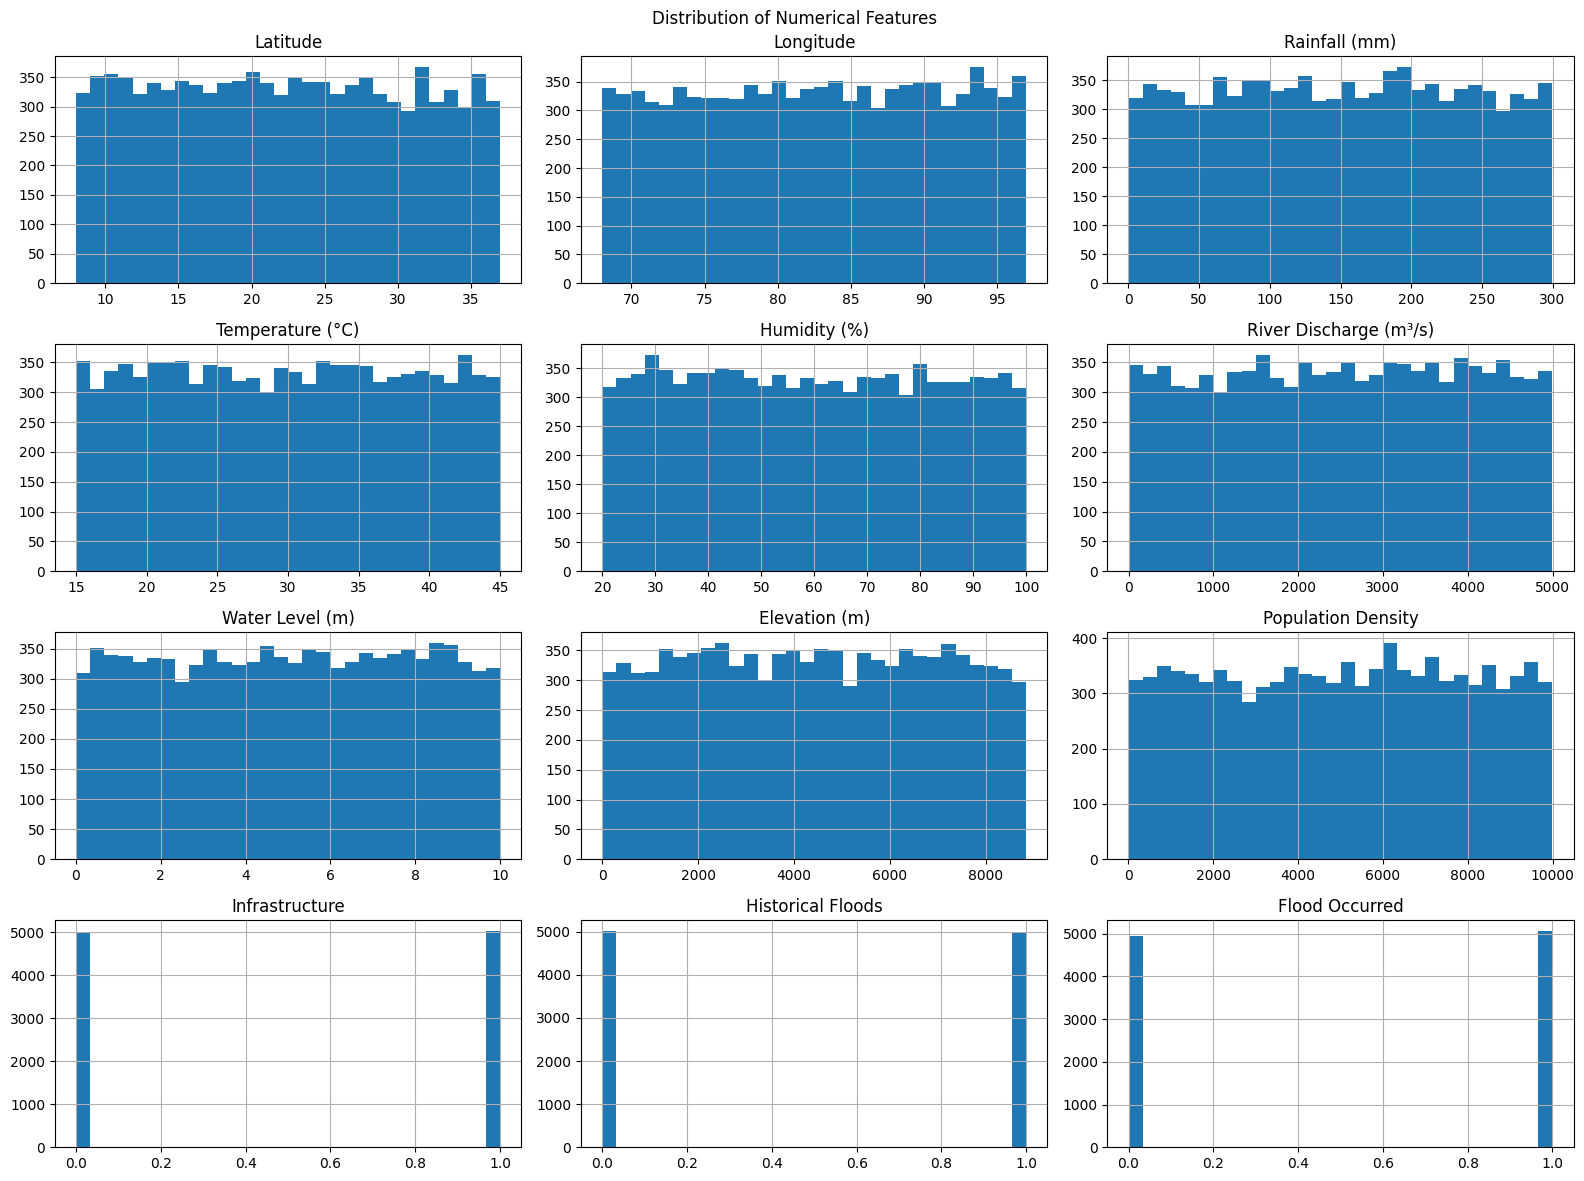

In [34]:
df[numeric_columns].hist(
    figsize=(16,12),
    bins=30
)

plt.suptitle("Distribution of Numerical Features")

plt.tight_layout()
plt.show()

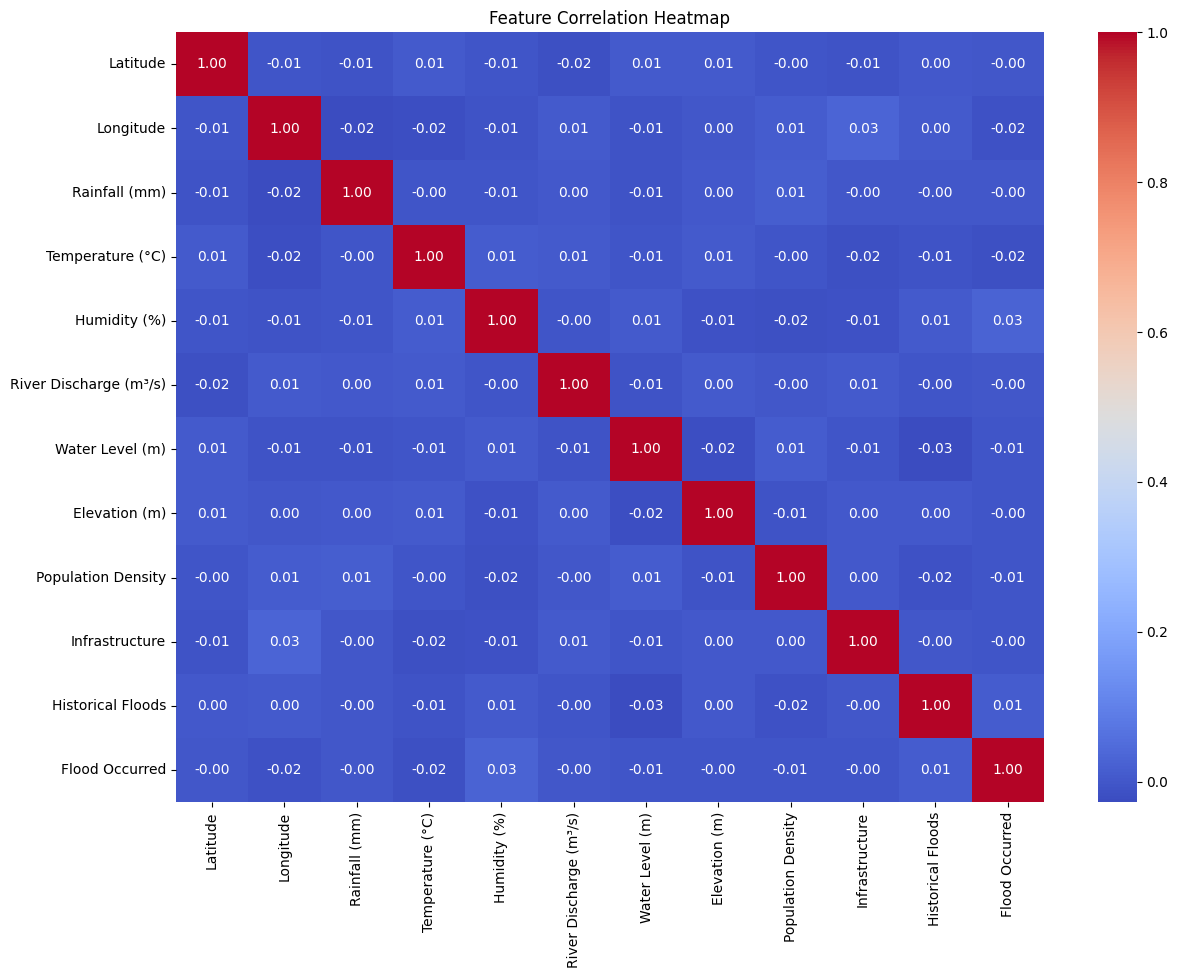

In [35]:
plt.figure(figsize=(14,10))

correlation = df[numeric_columns].corr()

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Feature Correlation Heatmap")

plt.show()

In [36]:
categorical_columns = df.select_dtypes(
    include=["object", "category"]
).columns

print("Categorical columns:")
print(categorical_columns.tolist())

Categorical columns:
['Land Cover', 'Soil Type']


In [37]:
for col in categorical_columns:
    print("\n", col)
    print(df[col].value_counts())


 Land Cover
Land Cover
Water Body      2046
Desert          2033
Forest          2005
Agricultural    1978
Urban           1938
Name: count, dtype: int64

 Soil Type
Soil Type
Peat     2052
Silt     2044
Clay     1978
Loam     1972
Sandy    1954
Name: count, dtype: int64


In [38]:
TARGET = "Flood Occurred"

X = df.drop(columns=[TARGET])
y = df[TARGET]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (10000, 13)
y shape: (10000,)


In [39]:
print("Features:")
print(X.columns.tolist())

Features:
['Latitude', 'Longitude', 'Rainfall (mm)', 'Temperature (°C)', 'Humidity (%)', 'River Discharge (m³/s)', 'Water Level (m)', 'Elevation (m)', 'Land Cover', 'Soil Type', 'Population Density', 'Infrastructure', 'Historical Floods']


In [40]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [41]:
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Numerical:", numeric_features)
print("Categorical:", categorical_features)

Numerical: ['Latitude', 'Longitude', 'Rainfall (mm)', 'Temperature (°C)', 'Humidity (%)', 'River Discharge (m³/s)', 'Water Level (m)', 'Elevation (m)', 'Population Density', 'Infrastructure', 'Historical Floods']
Categorical: ['Land Cover', 'Soil Type']


In [44]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore"
    ))
])

preprocessor = ColumnTransformer([
    (
        "numeric",
        numeric_transformer,
        numeric_features
    ),
    (
        "categorical",
        categorical_transformer,
        categorical_features
    )
])

In [45]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (8000, 13)
Testing data: (2000, 13)


In [46]:
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=2000,
        random_state=42
    ))
])

In [47]:
logistic_model.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Latitude', 'Longitude',
                                                   'Rainfall (mm)',
                                                   'Temperature (°C)',
                                                   'Humidity (%)',
                                                   'River Discharge (m³/s)',
                                                   'Water Level (m)',
                                                   'Elevation (m)',
                                                   'Population Density',
                                                   'Infrastructure',
                                                   'Historical Floods']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Land Cover',
                                                   'Soil Type'])])),
                ('classifier',
                 LogisticRegression(max_iter=2000, random_state=42))])

In [48]:
y_pred_lr = logistic_model.predict(X_test)

In [49]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

print("Logistic Regression")
print("=" * 40)

print(
    "Accuracy:",
    accuracy_score(y_test, y_pred_lr)
)

print(
    "Precision:",
    precision_score(
        y_test,
        y_pred_lr,
        average="weighted",
        zero_division=0
    )
)

print(
    "Recall:",
    recall_score(
        y_test,
        y_pred_lr,
        average="weighted",
        zero_division=0
    )
)

print(
    "F1 Score:",
    f1_score(
        y_test,
        y_pred_lr,
        average="weighted",
        zero_division=0
    )
)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_lr,
        zero_division=0
    )
)

Logistic Regression
Accuracy: 0.4965
Precision: 0.49561544489103576
Recall: 0.4965
F1 Score: 0.4935096261429353

Classification Report:
              precision    recall  f1-score   support

           0       0.49      0.42      0.45       989
           1       0.50      0.57      0.53      1011

    accuracy                           0.50      2000
   macro avg       0.50      0.50      0.49      2000
weighted avg       0.50      0.50      0.49      2000



In [50]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = Pipeline([
    ("preprocessor", preprocessor),

    ("classifier", RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        random_state=42,
        n_jobs=-1
    ))
])

In [51]:
random_forest_model.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Latitude', 'Longitude',
                                                   'Rainfall (mm)',
                                                   'Temperature (°C)',
                                                   'Humidity (%)',
                                                   'River Discharge (m³/s)',
                                                   'Water Level (m)',
                                                   'Elevation (m)',
                                                   'Population Density',
                                                   'Infrastructure',
                                                   'Historical Floods']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Land Cover',
                                                   'Soil Type'])])),
                ('classifier',
                 RandomForestClassifier(n_estimators=300, n_jobs=-1,
                                        random_state=42))])

In [53]:
y_pred_rf = random_forest_model.predict(X_test)

In [58]:
print("Random Forest")
print("=" * 40)

print(
    "Accuracy:",
    accuracy_score(y_test, y_pred_rf)
)

print(
    "Precision:",
    precision_score(
        y_test,
        y_pred_rf,
        average="weighted",
        zero_division=0
    )
)

print(
    "Recall:",
    recall_score(
        y_test,
        y_pred_rf,
        average="weighted",
        zero_division=0
    )
)

print(
    "F1 Score:",
    f1_score(
        y_test,
        y_pred_rf,
        average="weighted",
        zero_division=0
    )
)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_rf,
        zero_division=0
    )
)

Random Forest
Accuracy: 0.5055
Precision: 0.50543017578125
Recall: 0.5055
F1 Score: 0.5054437333933518

Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.49      0.50       989
           1       0.51      0.52      0.51      1011

    accuracy                           0.51      2000
   macro avg       0.51      0.51      0.51      2000
weighted avg       0.51      0.51      0.51      2000



In [60]:
from sklearn.ensemble import GradientBoostingClassifier

gradient_boosting_model = Pipeline([
    ("preprocessor", preprocessor),

    ("classifier", GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

In [61]:
gradient_boosting_model.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Latitude', 'Longitude',
                                                   'Rainfall (mm)',
                                                   'Temperature (°C)',
                                                   'Humidity (%)',
                                                   'River Discharge (m³/s)',
                                                   'Water Level (m)',
                                                   'Elevation (m)',
                                                   'Population Density',
                                                   'Infrastructure',
                                                   'Historical Floods']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Land Cover',
                                                   'Soil Type'])])),
                ('classifier',
                 GradientBoostingClassifier(learning_rate=0.05,
                                            n_estimators=200,
                                            random_state=42))])

In [62]:
y_pred_gb = gradient_boosting_model.predict(X_test)

In [65]:
print("Gradient Boosting")
print("=" * 40)

print(
    "Accuracy:",
    accuracy_score(y_test, y_pred_gb)
)

print(
    "Precision:",
    precision_score(
        y_test,
        y_pred_gb,
        average="weighted",
        zero_division=0
    )
)

print(
    "Recall:",
    recall_score(
        y_test,
        y_pred_gb,
        average="weighted",
        zero_division=0
    )
)

print(
    "F1 Score:",
    f1_score(
        y_test,
        y_pred_gb,
        average="weighted",
        zero_division=0
    )
)

Gradient Boosting
Accuracy: 0.491
Precision: 0.489670739485149
Recall: 0.491
F1 Score: 0.48642414141414136


In [66]:
print("Gradient Boosting")
print("=" * 40)

print(
    "Accuracy:",
    accuracy_score(y_test, y_pred_gb)
)

print(
    "Precision:",
    precision_score(
        y_test,
        y_pred_gb,
        average="weighted",
        zero_division=0
    )
)

print(
    "Recall:",
    recall_score(
        y_test,
        y_pred_gb,
        average="weighted",
        zero_division=0
    )
)

print(
    "F1 Score:",
    f1_score(
        y_test,
        y_pred_gb,
        average="weighted",
        zero_division=0
    )
)

Gradient Boosting
Accuracy: 0.491
Precision: 0.489670739485149
Recall: 0.491
F1 Score: 0.48642414141414136


In [68]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],

    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_gb)
    ],

    "Precision": [
        precision_score(
            y_test, y_pred_lr,
            average="weighted",
            zero_division=0
        ),
        precision_score(
            y_test, y_pred_rf,
            average="weighted",
            zero_division=0
        ),
        precision_score(
            y_test, y_pred_gb,
            average="weighted",
            zero_division=0
        )
    ],

    "Recall": [
        recall_score(
            y_test, y_pred_lr,
            average="weighted",
            zero_division=0
        ),
        recall_score(
            y_test, y_pred_rf,
            average="weighted",
            zero_division=0
        ),
        recall_score(
            y_test, y_pred_gb,
            average="weighted",
            zero_division=0
        )
    ],

    "F1 Score": [
        f1_score(
            y_test, y_pred_lr,
            average="weighted",
            zero_division=0
        ),
        f1_score(
            y_test, y_pred_rf,
            average="weighted",
            zero_division=0
        ),
        f1_score(
            y_test, y_pred_gb,
            average="weighted",
            zero_division=0
        )
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.4965,0.495615,0.4965,0.493510
1,Random Forest,0.5055,0.505430,0.5055,0.505444
2,Gradient Boosting,0.4910,0.489671,0.4910,0.486424


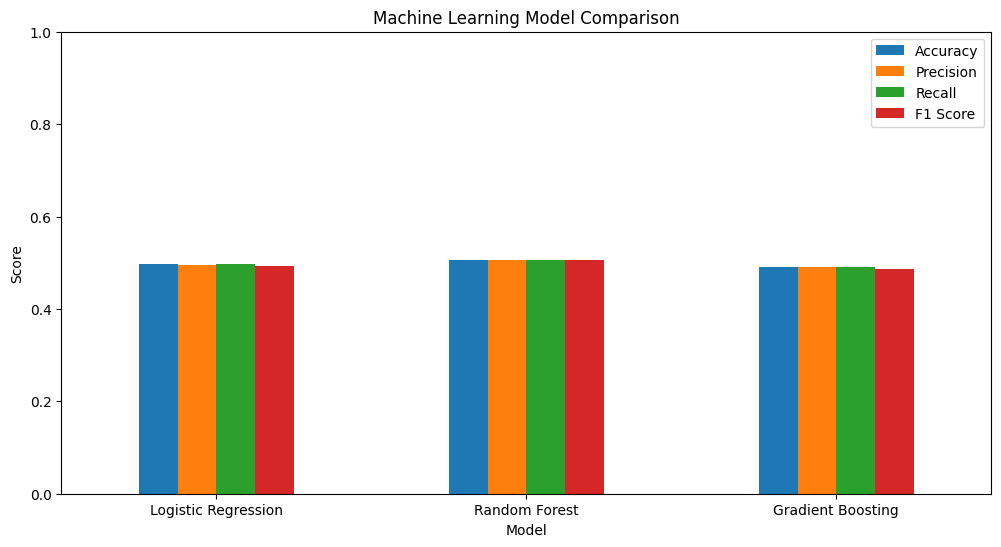

In [69]:
results.set_index("Model").plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Machine Learning Model Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)

plt.show()

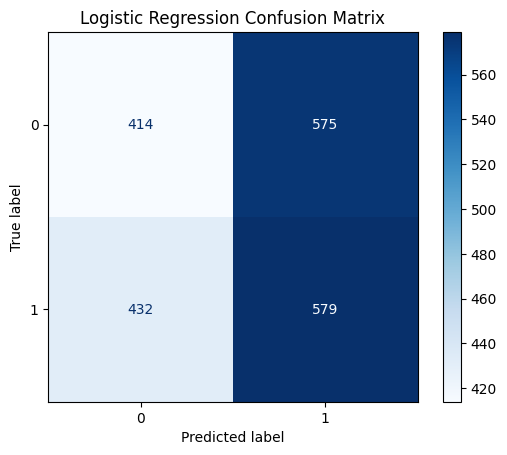

In [70]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_lr,
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")
plt.show()

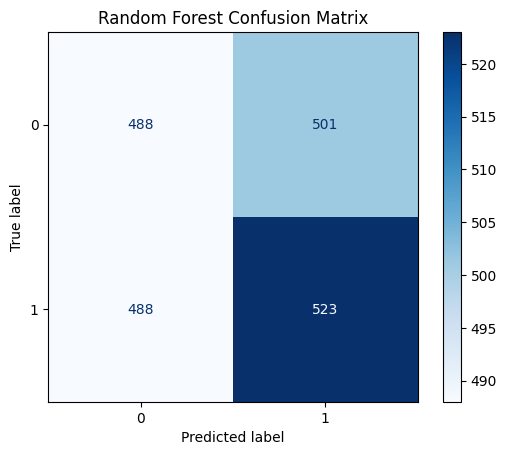

In [71]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    cmap="Blues"
)

plt.title("Random Forest Confusion Matrix")
plt.show()

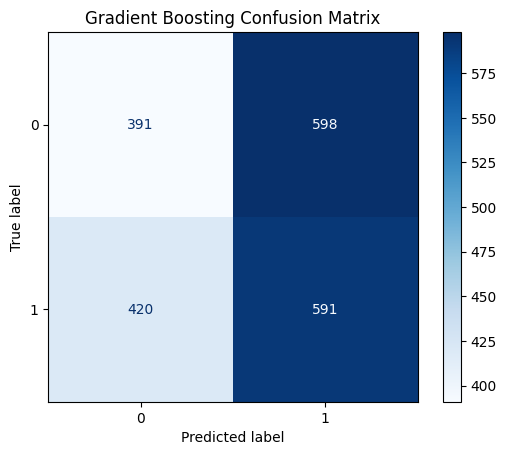

In [72]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_gb,
    cmap="Blues"
)

plt.title("Gradient Boosting Confusion Matrix")
plt.show()

In [73]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [75]:
rf_cv_scores = cross_val_score(
    random_forest_model,
    X,
    y,
    cv=cv,
    scoring="f1_weighted",
    n_jobs=-1
)

print("Random Forest CV F1 scores:")
print(rf_cv_scores)

print(
    "Mean CV F1:",
    rf_cv_scores.mean()
)

Random Forest CV F1 scores:
[0.50634161 0.50539895 0.51604938 0.51007372 0.51325716]
Mean CV F1: 0.5102241656766012


In [76]:
import joblib

joblib.dump(
    random_forest_model,
    "flood_risk_random_forest.pkl"
)

print("Model saved successfully!")

Model saved successfully!


In [78]:
from google.colab import files

files.download(
    "flood_risk_random_forest.pkl"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [80]:
print(df.columns.tolist())

['Latitude', 'Longitude', 'Rainfall (mm)', 'Temperature (°C)', 'Humidity (%)', 'River Discharge (m³/s)', 'Water Level (m)', 'Elevation (m)', 'Land Cover', 'Soil Type', 'Population Density', 'Infrastructure', 'Historical Floods', 'Flood Occurred']


In [81]:
print(df["Flood Occurred"].value_counts())

Flood Occurred
1    5057
0    4943
Name: count, dtype: int64


In [82]:
def predict_flood(
    latitude,
    longitude,
    rainfall,
    temperature,
    humidity,
    river_discharge,
    water_level,
    elevation,
    land_cover,
    soil_type,
    population_density,
    infrastructure,
    historical_floods
):

    new_data = pd.DataFrame({
        "Latitude": [latitude],
        "Longitude": [longitude],
        "Rainfall (mm)": [rainfall],
        "Temperature (°C)": [temperature],
        "Humidity (%)": [humidity],
        "River Discharge (m³/s)": [river_discharge],
        "Water Level (m)": [water_level],
        "Elevation (m)": [elevation],
        "Land Cover": [land_cover],
        "Soil Type": [soil_type],
        "Population Density": [population_density],
        "Infrastructure": [infrastructure],
        "Historical Floods": [historical_floods]
    })

    prediction = random_forest_model.predict(new_data)[0]

    probability = random_forest_model.predict_proba(new_data)[0][1]

    print("================================")
    print("      FLOOD PREDICTION")
    print("================================")

    if prediction == 1:
        print("Prediction: FLOOD")
    else:
        print("Prediction: NO FLOOD")

    print(f"Flood Probability: {probability * 100:.2f}%")
    print("================================")

In [85]:
import requests
import pandas as pd
from datetime import datetime

# Bengaluru coordinates
latitude = 12.9716
longitude = 77.5946

url = (
    "https://api.open-meteo.com/v1/forecast"
    f"?latitude={latitude}"
    f"&longitude={longitude}"
    "&current=temperature_2m,relative_humidity_2m,precipitation,rain,wind_speed_10m"
    "&timezone=Asia%2FKolkata"
)

response = requests.get(url)

if response.status_code == 200:
    weather = response.json()
    print("Live weather data received successfully!")
else:
    print("Error:", response.status_code)

Live weather data received successfully!


Nearest dataset location:
Latitude                    12.983054
Longitude                   77.542822
Rainfall (mm)              109.321412
Temperature (°C)            32.694322
Humidity (%)                49.622592
River Discharge (m³/s)    4065.758959
Water Level (m)              1.626393
Elevation (m)             3973.608395
Land Cover                     Forest
Soil Type                        Loam
Population Density        1606.236316
Infrastructure                      0
Historical Floods                   1
Flood Occurred                      0
Name: 4540, dtype: object


In [89]:
live_input = nearest_row.drop("Flood Occurred").copy()

live_input["Latitude"] = latitude
live_input["Longitude"] = longitude

live_input["Temperature (°C)"] = current["temperature_2m"]
live_input["Humidity (%)"] = current["relative_humidity_2m"]
live_input["Rainfall (mm)"] = current["precipitation"]

live_input = pd.DataFrame([live_input])

print("Live prediction input:")
display(live_input)

Live prediction input:


,Latitude,Longitude,Rainfall (mm),Temperature (°C),Humidity (%),River Discharge (m³/s),Water Level (m),Elevation (m),Land Cover,Soil Type,Population Density,Infrastructure,Historical Floods
4540,12.9716,77.5946,0.0,30.5,48,4065.758959,1.626393,3973.608395,Forest,Loam,1606.236316,0,1


In [123]:
print("╔══════════════════════════════════════╗")
print("║     FLOOD RISK MONITORING SYSTEM     ║")
print("╠══════════════════════════════════════╣")
print(f"║ Location: bengaluru               ║")
print(f"║ Temperature: {current['temperature_2m']:>6} °C             ║")
print(f"║ Humidity:    {current['relative_humidity_2m']:>6} %              ║")
print(f"║ Rainfall:    {current['precipitation']:>6} mm             ║")
print(f"║ Wind Speed:  {current['wind_speed_10m']:>6} km/h           ║")
print("╠══════════════════════════════════════╣")

if live_prediction == 1:
    print("║ ⚠️ FLOOD PREDICTION: YES             ║")
else:
    print("║ ✅ FLOOD PREDICTION: NO              ║")

print(f"║ Probability: {live_probability*100:>6.2f}%              ║")
print("╚══════════════════════════════════════╝")

╔══════════════════════════════════════╗
║     FLOOD RISK MONITORING SYSTEM     ║
╠══════════════════════════════════════╣
║ Location: bengaluru               ║
║ Temperature:   30.9 °C             ║
║ Humidity:        47 %              ║
║ Rainfall:       0.0 mm             ║
║ Wind Speed:     9.4 km/h           ║
╠══════════════════════════════════════╣
║ ✅ FLOOD PREDICTION: NO              ║
║ Probability:  42.33%              ║
╚══════════════════════════════════════╝


In [122]:
import requests

latitude = 12.9716
longitude = 77.5946

url = (
    f"https://api.open-meteo.com/v1/forecast?"
    f"latitude={latitude}&longitude={longitude}"
    "&current=temperature_2m,relative_humidity_2m,"
    "precipitation,rain,wind_speed_10m"
    "&timezone=Asia%2FKolkata"
)

response = requests.get(url)
weather = response.json()

current = weather["current"]

print("======================================")
print("       LIVE WEATHER DATA")
print("======================================")
print("Location: Bengaluru")
print("Time:", current["time"])
print("Temperature:", current["temperature_2m"], "°C")
print("Humidity:", current["relative_humidity_2m"], "%")
print("Rainfall:", current["precipitation"], "mm")
print("Wind Speed:", current["wind_speed_10m"], "km/h")
print("======================================")

       LIVE WEATHER DATA
Location: Bengaluru
Time: 2026-09-18T13:45
Temperature: 30.9 °C
Humidity: 47 %
Rainfall: 0.0 mm
Wind Speed: 9.4 km/h
